In [1]:
# =====================================================
# IMPORTS
# =====================================================
import xarray as xr
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from shapely.geometry import Point
from shapely.prepared import prep
from cartopy.io.shapereader import Reader as ShapeReader
import dask
# =====================================================
# CONFIG
# =====================================================
xr.set_options(keep_attrs=True)

base_dir = "/home/lacrio/DATA/term_cal/res_new"
csv_days = "/home/lacrio/DATA/term_cal/range_date_evets.csv"
nc_pattern = "era5_t_uvw_{start}_{end}_thermo_budget.nc"

vars_plot = ["dT/dt", "adv_h", "adv_v", "Q"]
titles = ["dT/dt", "Horizontal Advection", "Vertical Advection", "Diabatic Heating"]


In [2]:
def load_event(row, i, rel_time_axis):

    start = pd.to_datetime(row["start_date"])
    end   = pd.to_datetime(row["end_date"])
    central = pd.to_datetime(row["event_date"]).replace(hour=12)

    path = os.path.join(
        base_dir,
        nc_pattern.format(
            start=start.strftime("%Y%m%d"),
            end=end.strftime("%Y%m%d")
        )
    )

    if not os.path.exists(path):
        print(f"⚠️ Missing: {path}")
        return None

    # --- Open dataset ---
    #ds = xr.open_dataset(path)[vars_plot].astype("float32")
    ds = xr.open_dataset(path, chunks="auto")

    time_coord = "valid_time" if "valid_time" in ds.coords else "time"

    # --- Build integer relative time (KEY FIX) ---
    time_vals = ds[time_coord].values
    rel_time = ((time_vals - np.datetime64(central)) / np.timedelta64(1, "h")).astype("int32")

    ds = ds.assign_coords({time_coord: rel_time})
    ds = ds.rename({time_coord: "time"})

    # --- Select window ---
    ds = ds.sel(time=slice(rel_time_axis.min(), rel_time_axis.max()))

    # --- Reindex to FORCE SAME TIME AXIS ---
    ds = ds.reindex(time=rel_time_axis)

    # --- Apply scaling AFTER alignment ---
    ds = ds * 3600

    # --- Add event dimension ---
    ds = ds.expand_dims(event=[i])

    return ds

In [3]:
df = pd.read_csv(csv_days)#[0:20]
rel_time_axis = np.arange(-96, 97, 1, dtype=np.int32)
df

,start_date,event_date,end_date
0,1980-02-11,1980-02-17,1980-02-23
1,1980-12-17,1980-12-23,1980-12-29
2,1981-01-20,1981-01-26,1981-02-01
3,1981-12-03,1981-12-09,1981-12-15
4,1982-02-24,1982-03-02,1982-03-08
...,...,...,...
89,2021-11-03,2021-11-09,2021-11-15
90,2021-12-02,2021-12-08,2021-12-14
91,2021-12-13,2021-12-19,2021-12-25
92,2022-02-01,2022-02-07,2022-02-13


In [4]:
datasets = []

for i, row in df.iterrows():

    ds_evt = load_event(row, i, rel_time_axis)

    if ds_evt is None:
        continue

    datasets.append(ds_evt)

    if i % 10 == 0:
        print(f"➡️ Added {i+1} events")

➡️ Added 1 events
➡️ Added 11 events
➡️ Added 21 events
➡️ Added 31 events
➡️ Added 41 events
➡️ Added 51 events
➡️ Added 61 events
➡️ Added 71 events
➡️ Added 81 events
➡️ Added 91 events


In [5]:
ds_comp = xr.concat(datasets, dim="event")

In [16]:
# =====================================================
# MASK FUNCTION (UNCHANGED)
# =====================================================
def mask_with_shapefile(ds, shp_path):

    geoms = [geom.simplify(0.05)
             for geom in ShapeReader(shp_path).geometries()]
    geoms = [prep(geom) for geom in geoms]

    lon = ds.longitude.values
    lat = ds.latitude.values

    lon2d, lat2d = np.meshgrid(lon, lat)
    mask = np.zeros(lon2d.shape, dtype=bool)

    print("🔹 Creating shapefile mask...")

    for i in range(lat2d.shape[0]):
        for j in range(lat2d.shape[1]):
            pt = Point(lon2d[i, j], lat2d[i, j])
            inside = any(geom.contains(pt) for geom in geoms)
            mask[i, j] = not inside

    print("✅ Mask ready")
    return mask


# =====================================================
# APPLY MASKS
# =====================================================
shp_path = "/home/lacrio/Patagonia-Antarctic_Peninsula/data/shp/Glaciers_NPI_SPI.shp"

mask_PI = mask_with_shapefile(ds_comp, shp_path)
ds_PI = ds_comp.where(mask_PI == False).mean(("latitude", "longitude", "event"))

print(ds_PI)

# Antarctic Peninsula
land_feature = cfeature.NaturalEarthFeature("physical", "land", "10m")
land_geom = [prep(geom) for geom in land_feature.geometries()]

lon2d, lat2d = np.meshgrid(ds_comp.longitude.values,
                           ds_comp.latitude.values)

mask_AP = np.zeros(lon2d.shape, dtype=bool)

print("🔹 Creating AP mask...")

for i in range(lon2d.shape[0]):
    for j in range(lon2d.shape[1]):
        pt = Point(lon2d[i, j], lat2d[i, j])
        if not any(geom.contains(pt) for geom in land_geom):
            mask_AP[i, j] = True

mask_AP[(lat2d < -68) | (lat2d > -60)] = True

ds_AP = ds_comp.where(mask_AP == False).mean(("latitude", "longitude", "event"))


🔹 Creating shapefile mask...
✅ Mask ready
<xarray.Dataset> Size: 6kB
Dimensions:  (time: 193)
Coordinates:
  * time     (time) int32 772B -96 -95 -94 -93 -92 -91 -90 ... 91 92 93 94 95 96
Data variables:
    dT_dt    (time) float64 2kB dask.array<chunksize=(193,), meta=np.ndarray>
    adv_h    (time) float64 2kB dask.array<chunksize=(193,), meta=np.ndarray>
    adv_v    (time) float32 772B dask.array<chunksize=(193,), meta=np.ndarray>
    Q        (time) float64 2kB dask.array<chunksize=(193,), meta=np.ndarray>
Attributes:
    description:  Thermodynamic budget at 700 hPa (NHESS method)
    history:      Computed from ERA5 single file
🔹 Creating AP mask...


In [17]:
ds_12UTC = ds_comp.sel(time = 0).mean('event')

In [8]:
# -----------------------------------------------------------------------------
# Plot configuration
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

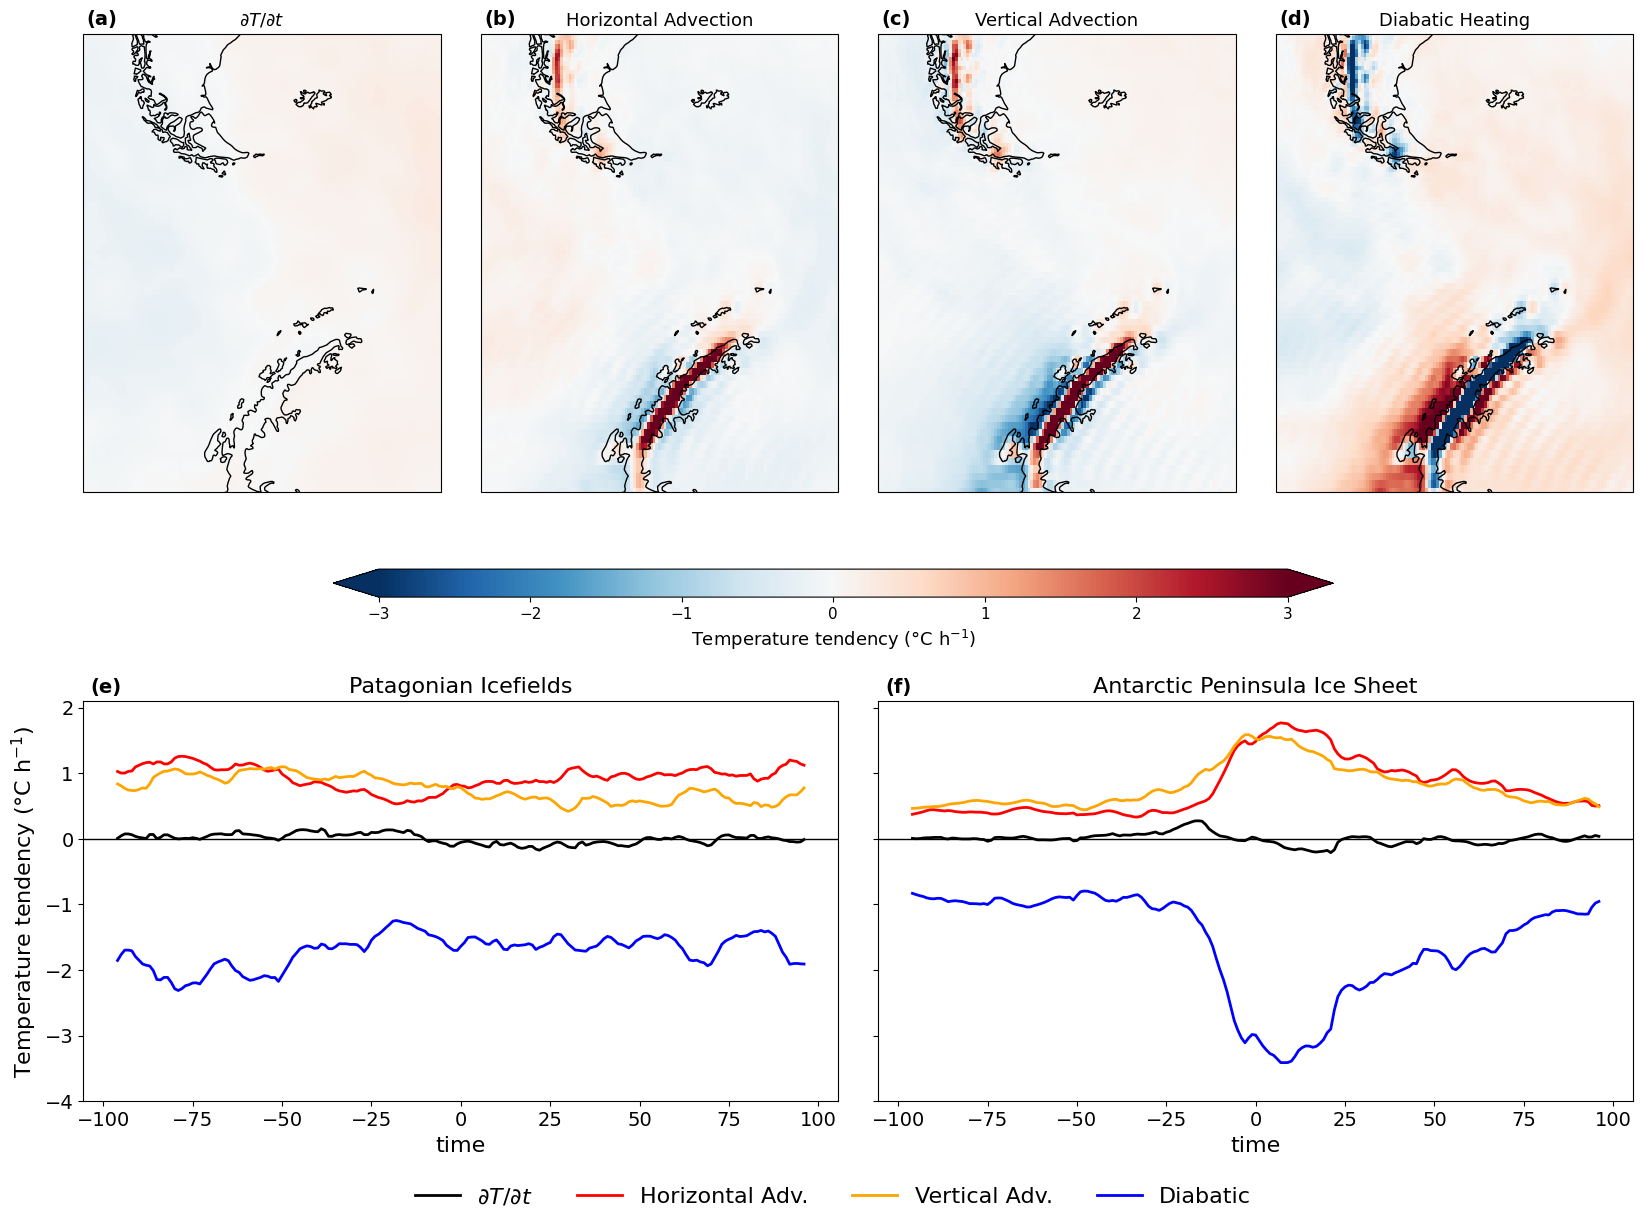

In [19]:
# =====================================================
# VARIABLES
# =====================================================
vars_plot = ["dT_dt", "adv_h", "adv_v", "Q"]

titles = [
    r"$\partial T / \partial t$",
    "Horizontal Advection",
    "Vertical Advection",
    "Diabatic Heating"
]

labels = {
    "dT_dt": r"$\partial T / \partial t$",
    "adv_h": "Horizontal Adv.",
    "adv_v": "Vertical Adv.",
    "Q": "Diabatic"
}

colors = {
    "dT_dt": "black",
    "adv_h": "red",
    "adv_v": "orange",
    "Q": "blue"
}

# =====================================================
# PLOTTING
# =====================================================
proj_map = ccrs.Mercator()
proj_data = ccrs.PlateCarree()

extent = [-80, -48, -68, -48]

fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    2, 8,
    height_ratios=[1.2, 1],
    hspace=0.45,
    wspace=0.25
)

# =====================================================
# MAPS (4 panels)
# =====================================================
for i, v in enumerate(vars_plot):

    ax = fig.add_subplot(gs[0, 2*i:2*i+2], projection=proj_map)

    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")

    im = ax.pcolormesh(
        ds_12UTC.longitude,
        ds_12UTC.latitude,
        ds_12UTC[v],
        cmap="RdBu_r",
        vmin=-3, vmax=3,
        shading="auto",
        transform=proj_data
    )

    ax.set_extent(extent)
    ax.set_title(titles[i], fontsize=13)

    ax.text(
        0.01, 1.02, f"({chr(97+i)})",
        transform=ax.transAxes,
        fontweight="bold",
        fontsize=14
    )

# =====================================================
# COLORBAR
# =====================================================
cax = fig.add_axes([0.25, 0.47, 0.5, 0.02])

cbar = fig.colorbar(im, cax=cax, orientation="horizontal", extend='both')
cbar.set_label("Temperature tendency (°C h$^{-1}$)", fontsize=13)
cbar.ax.tick_params(labelsize=11)

# =====================================================
# TIME SERIES
# =====================================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[1, 0:4])

for v in vars_plot:
    ds_PI[v].plot(
        ax=ax1,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax1.set_title("Patagonian Icefields", fontsize=16)
ax1.axhline(0, color="k", linewidth=1)

ax1.set_ylabel("Temperature tendency (°C h$^{-1}$)", fontsize=16)
ax1.set_ylim(-4.0, 2.1)
ax1.tick_params(labelsize=14)

ax1.text(0.01, 1.02, "(e)", transform=ax1.transAxes,
         fontsize=14, fontweight='bold')


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[1, 4:8])

for v in vars_plot:
    ds_AP[v].plot(
        ax=ax2,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax2.set_title("Antarctic Peninsula Ice Sheet", fontsize=16)
ax2.axhline(0, color="k", linewidth=1)

ax2.set_ylabel("")
ax2.set_ylim(-4.0, 2.1)
ax2.set_yticklabels([])
ax2.tick_params(labelsize=14)

ax2.text(0.01, 1.02, "(f)", transform=ax2.transAxes,
         fontsize=14, fontweight='bold')


# =====================================================
# 🔥 SHARED LEGEND (BEST PRACTICE)
# =====================================================
handles, legend_labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=16,
    bbox_to_anchor=(0.5, 0.02)
)

# =====================================================
# SAVE
# =====================================================
os.makedirs("./fig", exist_ok=True)

fig.savefig(
    "./fig/temp_tendency_4vars.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
filename = "/home/lacrio/DATA/term_cal/res_new/era5_t_uvw_20200204_20200216_thermo_budget.nc"
ds = xr.open_dataset(filename) * 3600

ds_12UTC = ds.sel(valid_time = '20200207T12')

ds_AP = ds.where(mask_AP == False).mean(("latitude", "longitude"))
ds_PI = ds.where(mask_PI == False).mean(("latitude", "longitude"))


In [11]:
df = ds_AP.to_dataframe() 
df['sum_terms'] = df[['adv_h', 'adv_v', 'Q']].sum(axis=1)
df

,dT_dt,adv_h,adv_v,Q,sum_terms
valid_time,,,,,
2020-02-04 00:00:00,0.061954,0.013670,0.269650,-0.221365,0.061954
2020-02-04 01:00:00,0.047856,0.001456,0.297759,-0.251358,0.047856
2020-02-04 02:00:00,0.001249,0.003953,0.220496,-0.223199,0.001249
2020-02-04 03:00:00,-0.048081,0.012203,0.167332,-0.227616,-0.048081
2020-02-04 04:00:00,-0.051068,0.015942,0.132665,-0.199676,-0.051068
...,...,...,...,...,...
2020-02-16 19:00:00,-0.037768,-0.025579,0.163912,-0.176100,-0.037768
2020-02-16 20:00:00,-0.043481,-0.008462,0.166845,-0.201865,-0.043481
2020-02-16 21:00:00,-0.105040,0.004963,0.177792,-0.287796,-0.105040


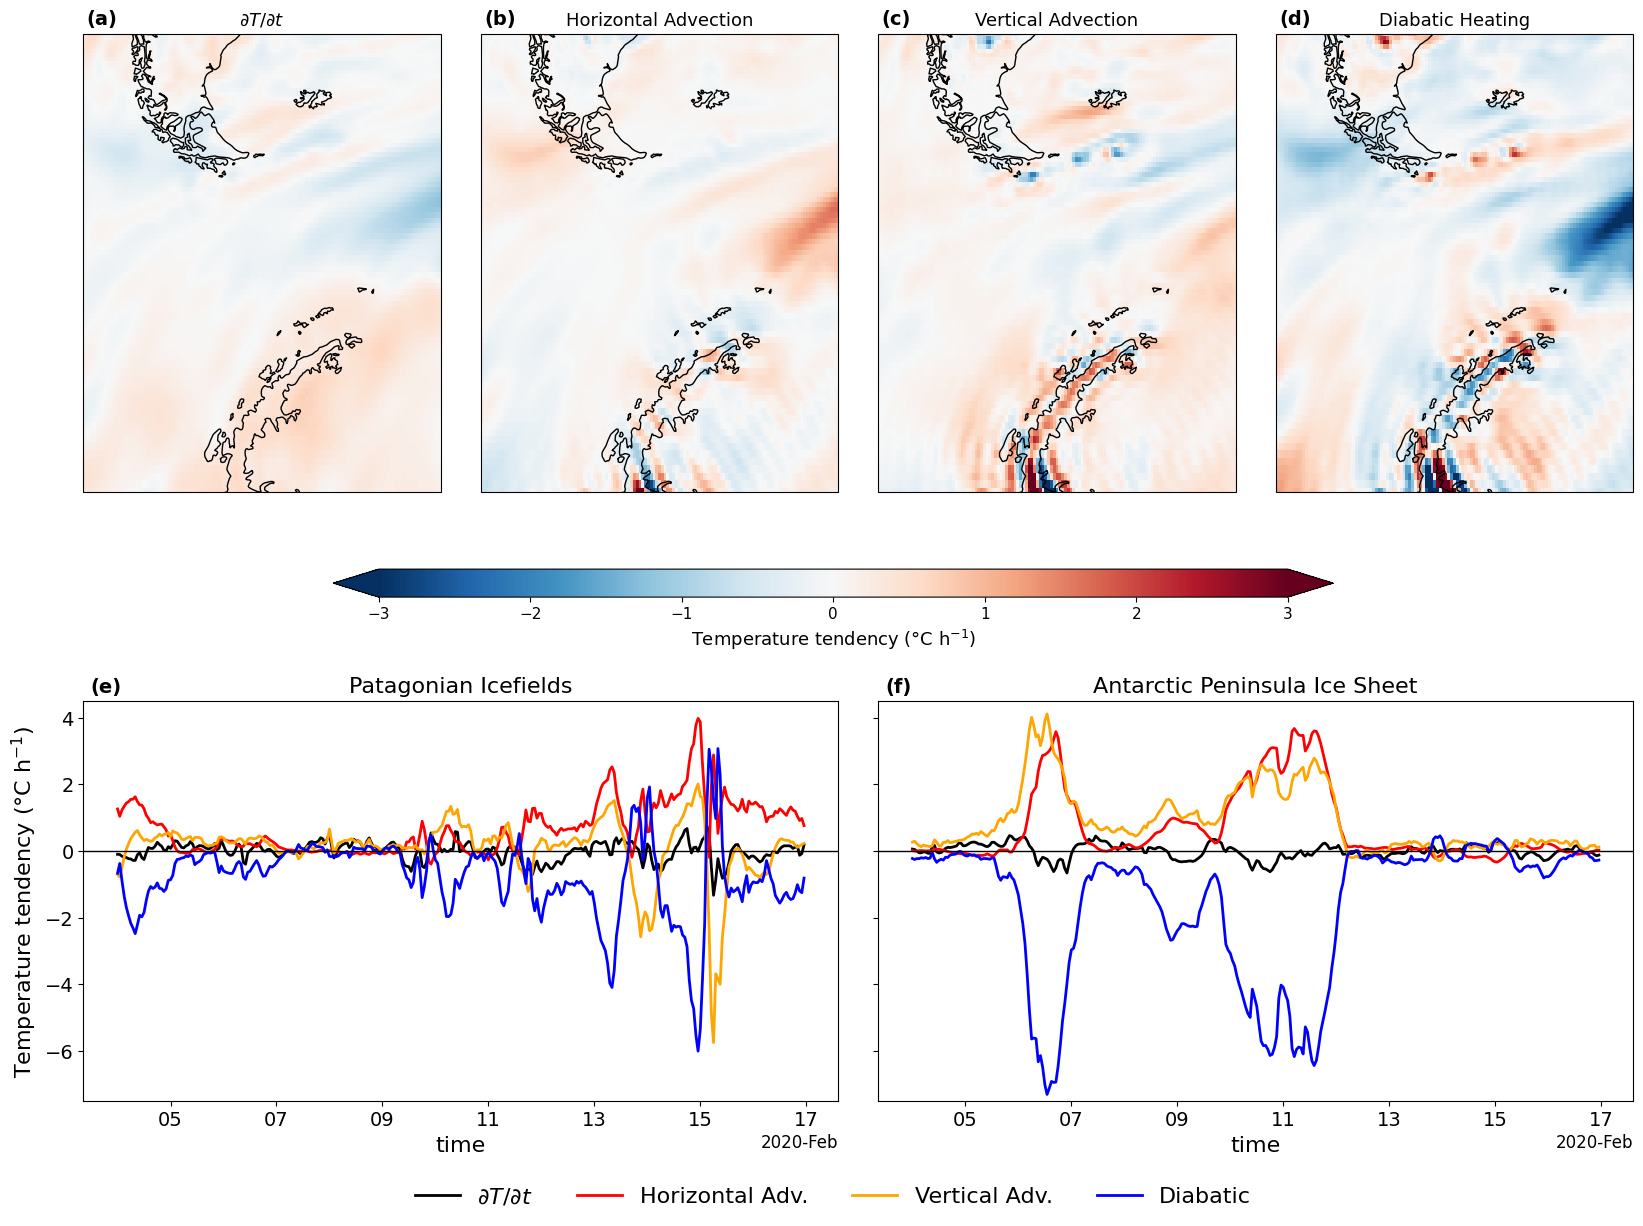

In [15]:
# =====================================================
# VARIABLES
# =====================================================
vars_plot = ["dT_dt", "adv_h", "adv_v", "Q"]

titles = [
    r"$\partial T / \partial t$",
    "Horizontal Advection",
    "Vertical Advection",
    "Diabatic Heating"
]

labels = {
    "dT_dt": r"$\partial T / \partial t$",
    "adv_h": "Horizontal Adv.",
    "adv_v": "Vertical Adv.",
    "Q": "Diabatic"
}

colors = {
    "dT_dt": "black",
    "adv_h": "red",
    "adv_v": "orange",
    "Q": "blue"
}

# =====================================================
# PLOTTING
# =====================================================
proj_map = ccrs.Mercator()
proj_data = ccrs.PlateCarree()

extent = [-80, -48, -68, -48]

fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    2, 8,
    height_ratios=[1.2, 1],
    hspace=0.45,
    wspace=0.25
)

# =====================================================
# MAPS (4 panels)
# =====================================================
for i, v in enumerate(vars_plot):

    ax = fig.add_subplot(gs[0, 2*i:2*i+2], projection=proj_map)

    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")

    im = ax.pcolormesh(
        ds_12UTC.longitude,
        ds_12UTC.latitude,
        ds_12UTC[v],
        cmap="RdBu_r",
        vmin=-3, vmax=3,
        shading="auto",
        transform=proj_data
    )

    ax.set_extent(extent)
    ax.set_title(titles[i], fontsize=13)

    ax.text(
        0.01, 1.02, f"({chr(97+i)})",
        transform=ax.transAxes,
        fontweight="bold",
        fontsize=14
    )

# =====================================================
# COLORBAR
# =====================================================
cax = fig.add_axes([0.25, 0.47, 0.5, 0.02])

cbar = fig.colorbar(im, cax=cax, orientation="horizontal", extend='both')
cbar.set_label("Temperature tendency (°C h$^{-1}$)", fontsize=13)
cbar.ax.tick_params(labelsize=11)


# =====================================================
# TIME SERIES
# =====================================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[1, 0:4])

for v in vars_plot:
    ds_PI[v].plot(
        ax=ax1,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax1.set_title("Patagonian Icefields", fontsize=16)
ax1.axhline(0, color="k", linewidth=1)

ax1.set_ylabel("Temperature tendency (°C h$^{-1}$)", fontsize=16)
ax1.set_ylim(-7.5, 4.5)
ax1.tick_params(labelsize=14)

ax1.text(0.01, 1.02, "(e)", transform=ax1.transAxes,
         fontsize=14, fontweight='bold')


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[1, 4:8])

for v in vars_plot:
    ds_AP[v].plot(
        ax=ax2,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax2.set_title("Antarctic Peninsula Ice Sheet", fontsize=16)
ax2.axhline(0, color="k", linewidth=1)

ax2.set_ylabel("")
ax2.set_ylim(-7.5, 4.5)
ax2.set_yticklabels([])
ax2.tick_params(labelsize=14)

ax2.text(0.01, 1.02, "(f)", transform=ax2.transAxes,
         fontsize=14, fontweight='bold')


# =====================================================
# 🔥 SHARED LEGEND (BEST PRACTICE)
# =====================================================
handles, legend_labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=16,
    bbox_to_anchor=(0.5, 0.02)
)


<Axes: xlabel='valid_time'>

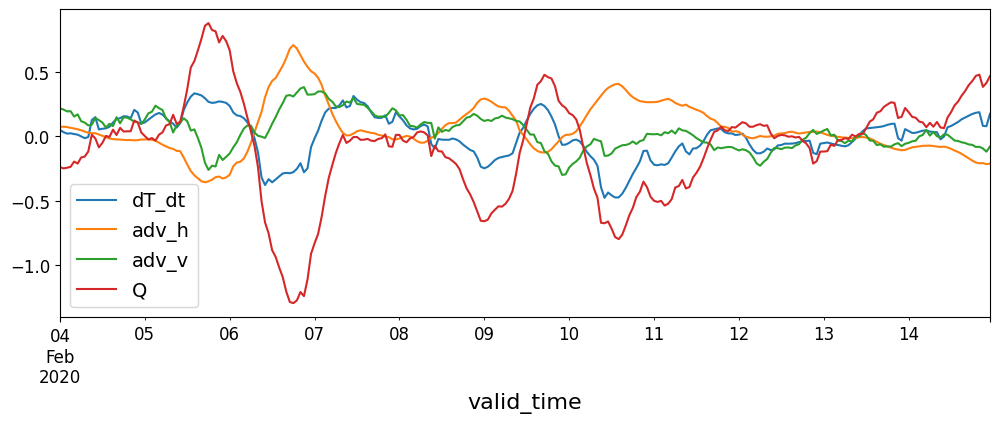

In [13]:
ds.sel(valid_time=slice('20200204','20200214'), latitude=slice(-70,-62), longitude=slice(-76,-55)).mean(('latitude', 'longitude')).to_dataframe().plot(figsize=(12,4))

In [14]:
'''
ds_AP = ds_comp.where(mask_AP == False).mean(("latitude", "longitude"))
ds_PI = ds_comp.where(mask_PI == False).mean(("latitude", "longitude"))
adv_h_t12 = ds_AP['adv_h'].sel(time=-12)

mask = (adv_h_t12 > 0).compute() 

event_ids = ds_AP['event'].where(mask, drop=True)

ds = ds_comp.sel(event=event_ids.event.values)

'''

'\nds_AP = ds_comp.where(mask_AP == False).mean(("latitude", "longitude"))\nds_PI = ds_comp.where(mask_PI == False).mean(("latitude", "longitude"))\nadv_h_t12 = ds_AP[\'adv_h\'].sel(time=-12)\n\nmask = (adv_h_t12 > 0).compute() \n\nevent_ids = ds_AP[\'event\'].where(mask, drop=True)\n\nds = ds_comp.sel(event=event_ids.event.values)\n\n'